In [26]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
from netmap.downstream import final_downstream


import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *

from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

import scipy.sparse as scs


import numpy as np
from pathlib import Path


In [ ]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/netmap/data/blood/reprocessed/blood-10x-rep1-cellbender-wk.h5ad')
experiment_name = 'cellbender-X'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/netmap/case_studies/blood/blood-10x-rep1-{experiment_name}/"
var = pd.read_csv(op.join(output_dir, f'blood-10x-rep1-{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'blood-10x-rep1-{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs,)

In [28]:
grn_adata

AnnData object with n_obs × n_vars = 7610 × 1042441
    obs: 'Unnamed: 0', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual'
    var: 'index', 'source', 'target', 'edge_sums', 'edge_means'

In [29]:
adata_raw

AnnData object with n_obs × n_vars = 7610 × 1021
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual'
    var: 'index', 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_semi_manual_colors', 'granular_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'majority_voting_colors', 'neighbors'

In [30]:
output_dir = Path(op.join(output_dir, "grn"))


In [31]:
grn_adata = retrieve_top_edges(grn_adata, output_dir, percentage=0.1 )

In [32]:
#sc.pp.filter_cells(adata_raw, min_genes=500)
#sc.pp.filter_genes(adata_raw, min_cells=50)
#adata.var =adata.var.set_index('gene_name')

In [33]:
adata_raw

AnnData object with n_obs × n_vars = 7610 × 1021
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual'
    var: 'index', 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_semi_manual_colors', 'granular_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'majority_voting_colors', 'neighbors'

In [34]:
adata_raw.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1758924 stored elements and shape (7610, 1021)>

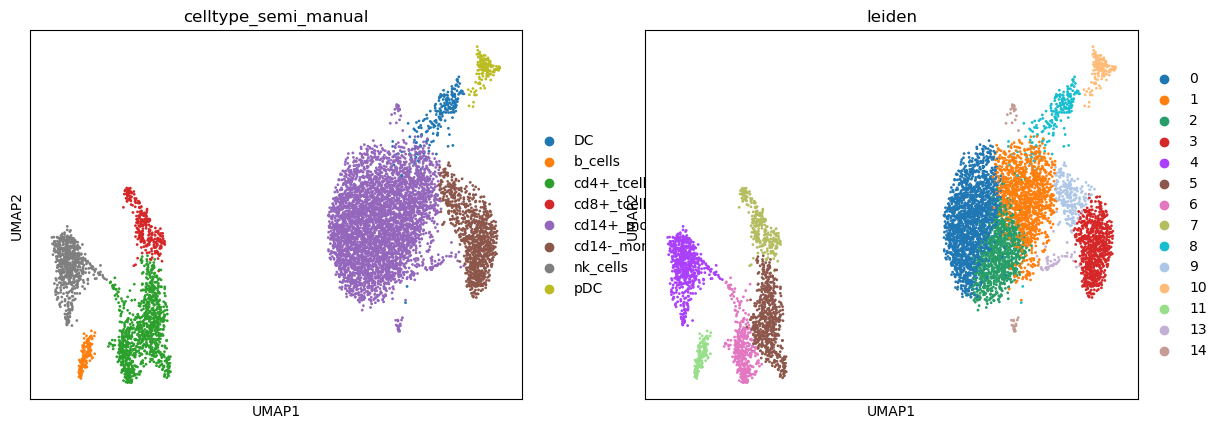

In [35]:
sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'leiden'])

In [36]:
grn_adata.var = grn_adata.var.set_index('index')



In [37]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)


In [38]:
sc.tl.leiden(grn_adata, resolution=0.20)

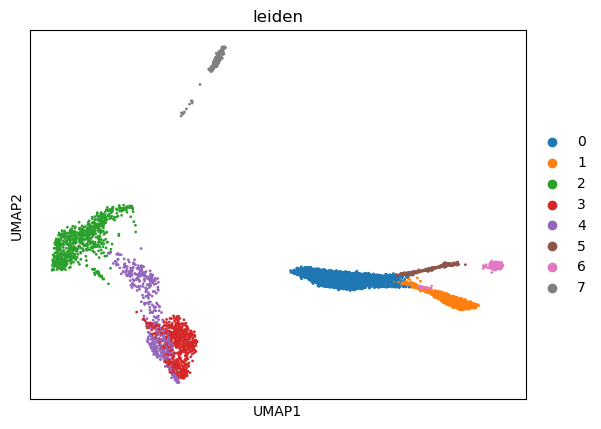

In [39]:
sc.pl.umap(grn_adata, color = 'leiden')

In [ ]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata, 'celltype_semi_manual', col_grn)
    print(f"{col_grn} score: {score}")


Clustering Score Evaluation
leiden score: 0.9555847568988174


In [41]:
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


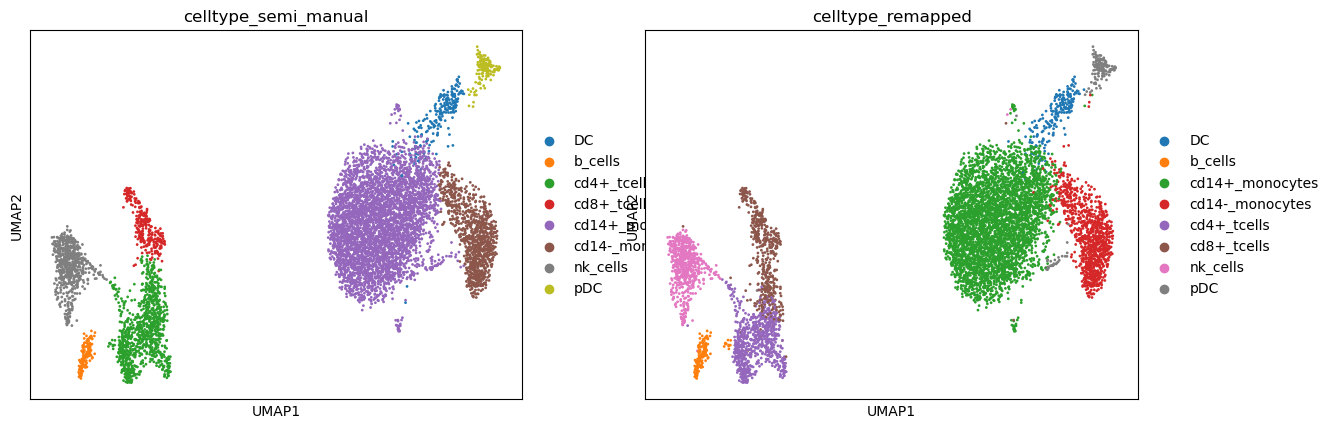

In [42]:
sc.pl.umap(adata_raw, color = ['celltype_semi_manual', 'celltype_remapped'])

In [43]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [44]:
grn_adata2.obs = grn_adata.obs

In [ ]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


AnnData object with n_obs × n_vars = 7610 × 1042441
    obs: 'Unnamed: 0', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero'
    layers: 'mask'

In [ ]:
index_list = np.where(grn_adata.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata, output_dir, index_list)

In [52]:
sc.tl.pca(grn_adata3, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata3, n_neighbors = 50)
sc.tl.umap(grn_adata3, n_components =50)


In [53]:
sc.tl.leiden(grn_adata3, resolution=0.28)


In [250]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata3, 'celltype_semi_manual' ,col_grn)
    print(f"{col_grn} score: {score}")


Clustering Score Evaluation
leiden score: 0.8168199737187911


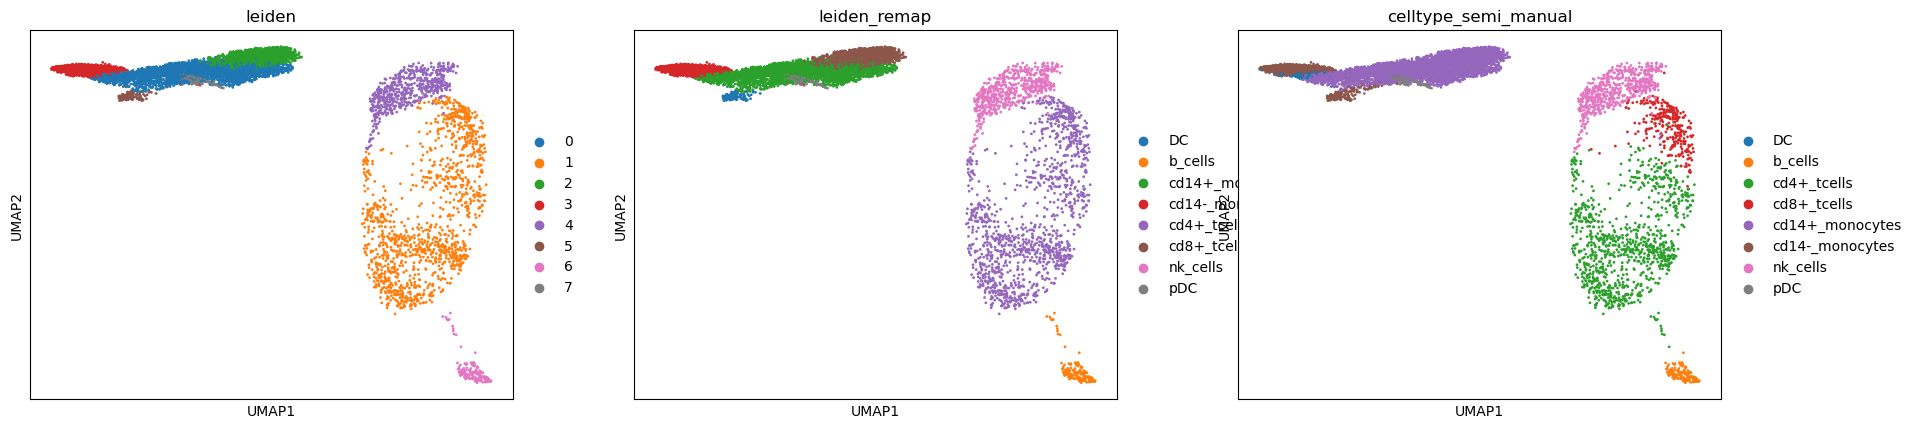

In [251]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'celltype_semi_manual'])

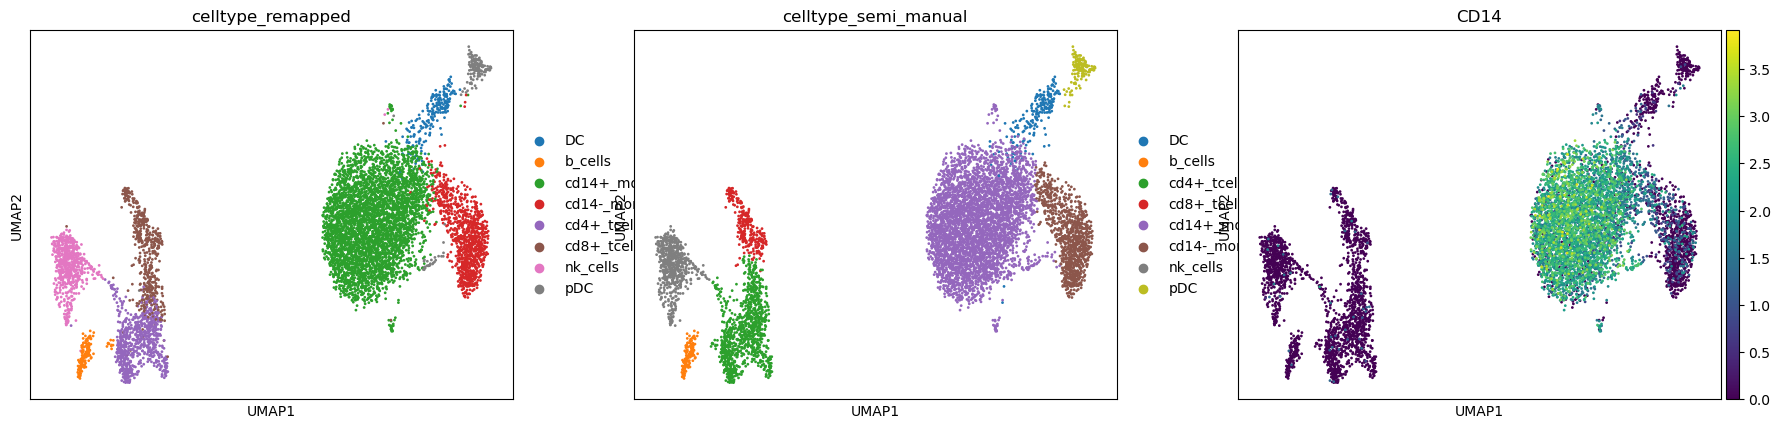

In [ ]:
sc.pl.umap(adata_raw, color = ['celltype_remapped', 'celltype_semi_manual', 'CD14', ])

In [225]:
cross_tab = pd.crosstab(grn_adata3.obs['celltype_semi_manual'], grn_adata3.obs['leiden_remap'])

In [226]:
cross_tab

leiden_remap,DC,b_cells,cd14+_monocytes,cd14-_monocytes,cd4+_tcells,cd8+_tcells,nk_cells,pDC
celltype_semi_manual,,,,,,,,
DC,0,0,16,200,0,0,0,1
b_cells,0,138,0,0,0,0,1,0
cd4+_tcells,0,12,0,0,768,205,0,1
cd8+_tcells,0,0,0,0,0,287,0,0
cd14+_monocytes,20,0,4163,22,0,2,2,27
cd14-_monocytes,199,0,11,770,0,0,0,0
nk_cells,0,0,0,0,2,1,611,0
pDC,1,0,2,3,0,0,0,145


In [241]:
grn_adata3.obs['leiden_remap'] = grn_adata2.obs['leiden_remap'].values

In [242]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'leiden_remap'

add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, tf_column='is_source_collectri')
# Compute UCell enrichment scores for each regulon signature
# Retain onlBICD1y the top-ranked regulons according to UCell signature enrichment



Selecting targets for cluster: DC
Hello
               source     target  edge_sums  edge_means  count_nonzero  \
edge_key                                                                 
TLE5_ABHD17A     TLE5    ABHD17A   0.600949    0.000079           4700   
TLE5_ABI3        TLE5       ABI3  -5.373277   -0.000706           2627   
TLE5_ACAP1       TLE5      ACAP1  14.179623    0.001863           2691   
TLE5_ACP1        TLE5       ACP1   8.308508    0.001092           2764   
TLE5_ACTN1       TLE5      ACTN1   2.586440    0.000340           2189   
...               ...        ...        ...         ...            ...   
TLE5_nan-12981   TLE5  nan-12981 -10.961580   -0.001440           1790   
TLE5_nan-1483    TLE5   nan-1483 -23.381128   -0.003072           4696   
TLE5_nan-19611   TLE5  nan-19611  -8.722339   -0.001146           2268   
TLE5_nan-5675    TLE5   nan-5675 -22.022938   -0.002894           4080   
TLE5_nan-8958    TLE5   nan-8958 -28.868906   -0.003794           5097  

In [243]:
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')

DC
b_cells
cd14+_monocytes
cd14-_monocytes
cd4+_tcells
cd8+_tcells
nk_cells
pDC


In [ ]:
#all_signatures = compute_signatures_UCell_scores(keep_edges, adata_raw, key='unique')

In [244]:
all_signatures = ad.AnnData(X = pd.DataFrame(regus), obs = adata_raw.obs, obsm = adata_raw.obsm)

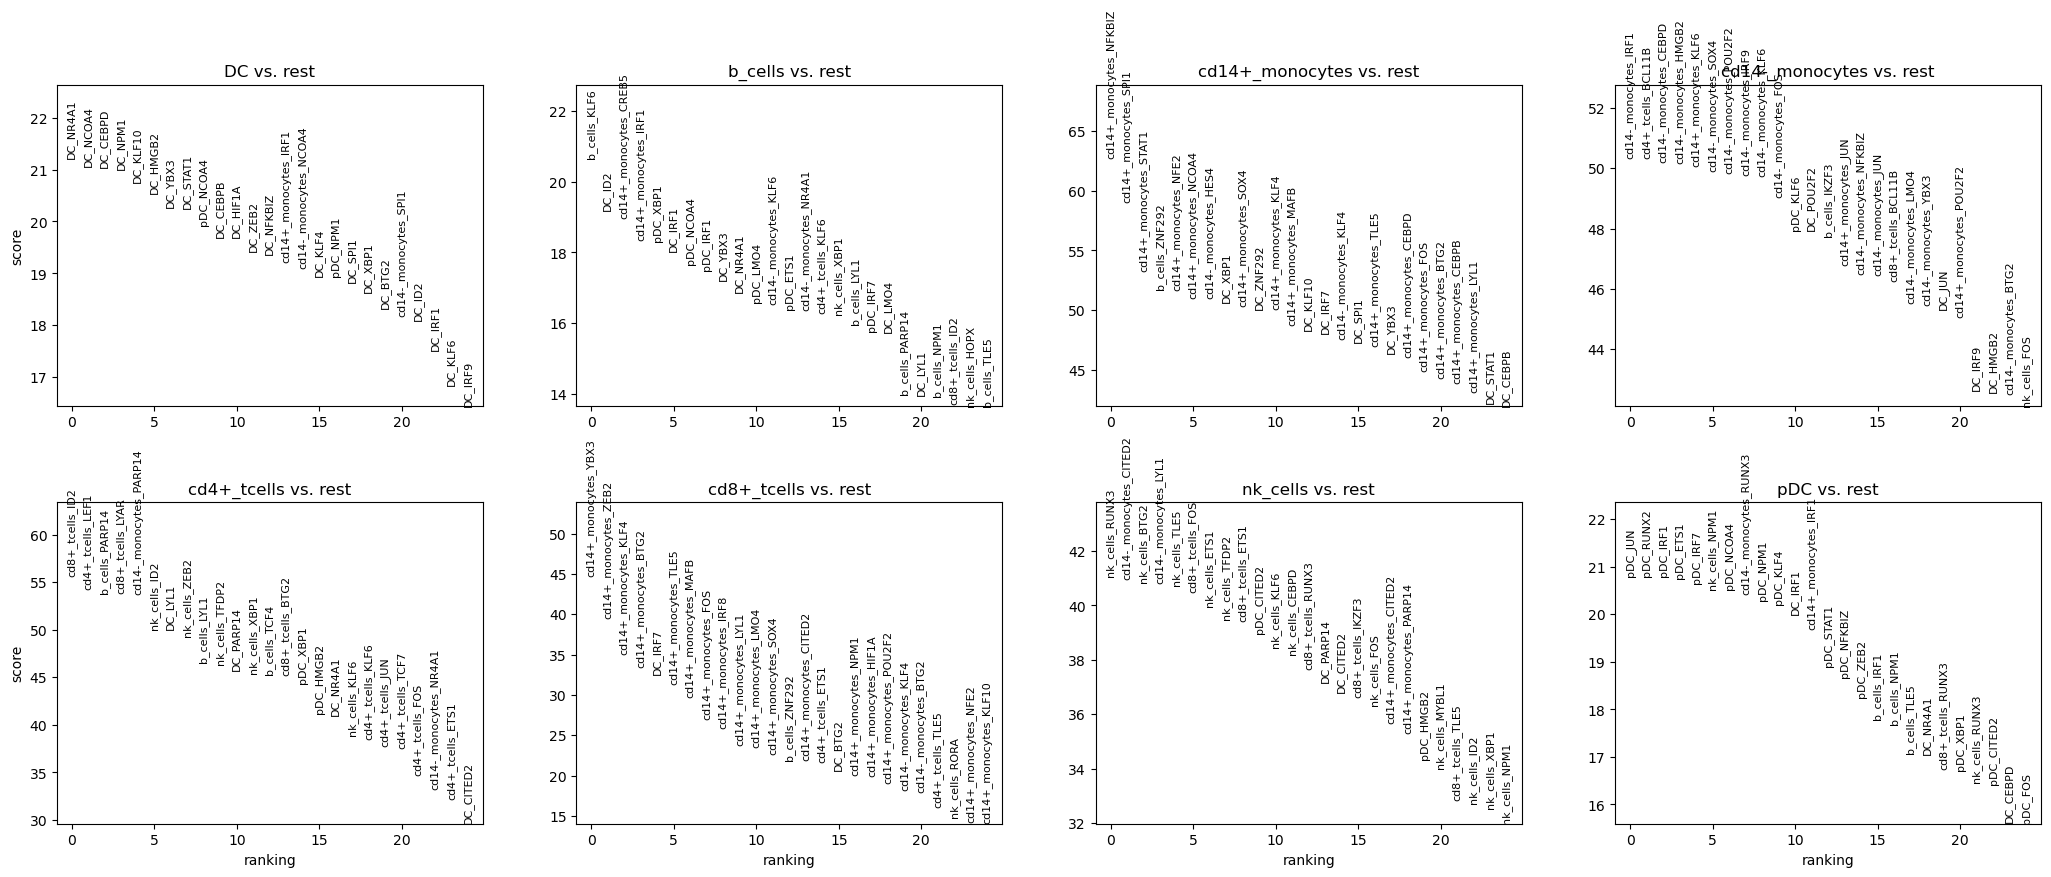

In [245]:
# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [246]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column=cluster_column)

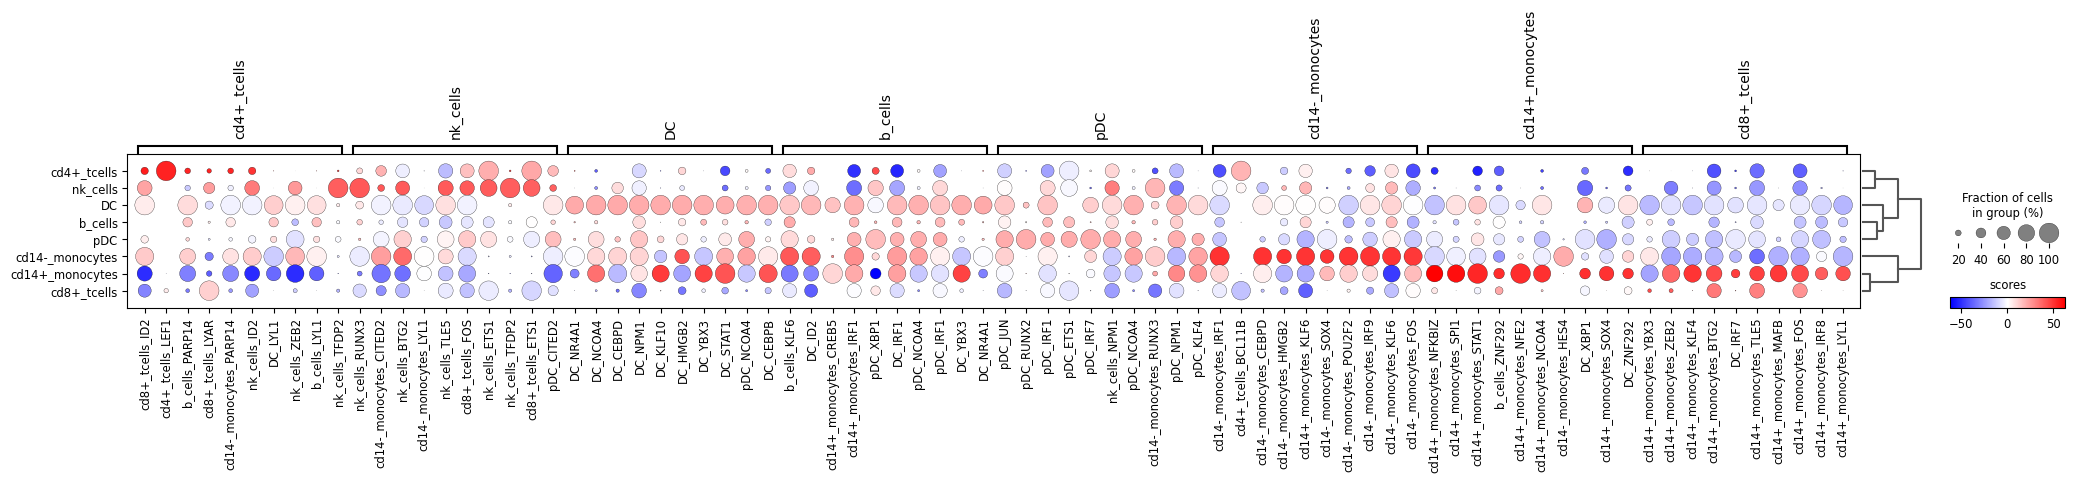

In [247]:
pp.show()

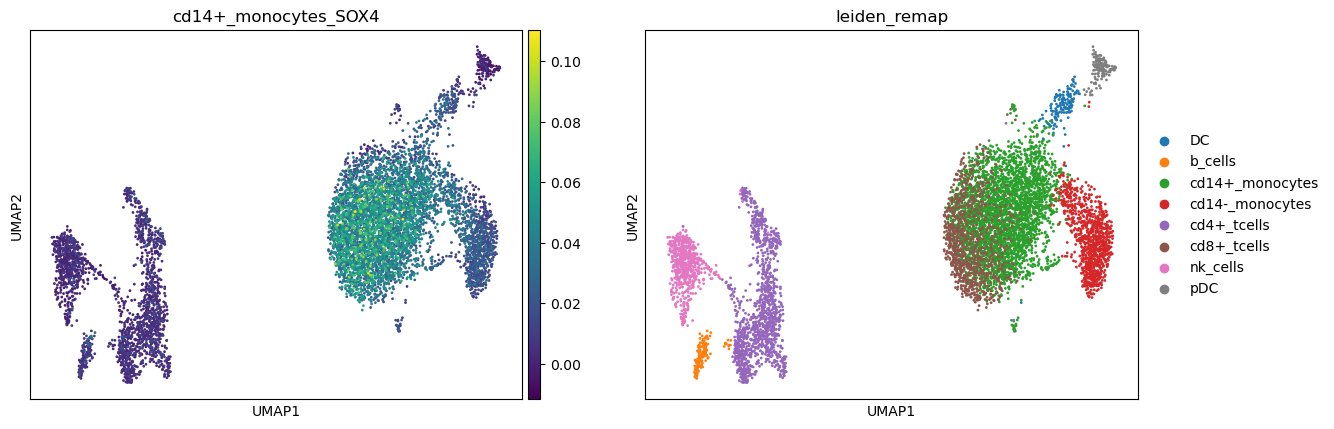

In [248]:
sc.pl.umap(all_signatures, color = ['cd14+_monocytes_SOX4', 'leiden_remap'])

In [238]:
re = keep_edges['unique']['cd14+_monocytes']['edges']
gene = 'SOX4'
re_sub = re[re.source == gene]
edges = re_sub.source + '_' + re_sub.target 

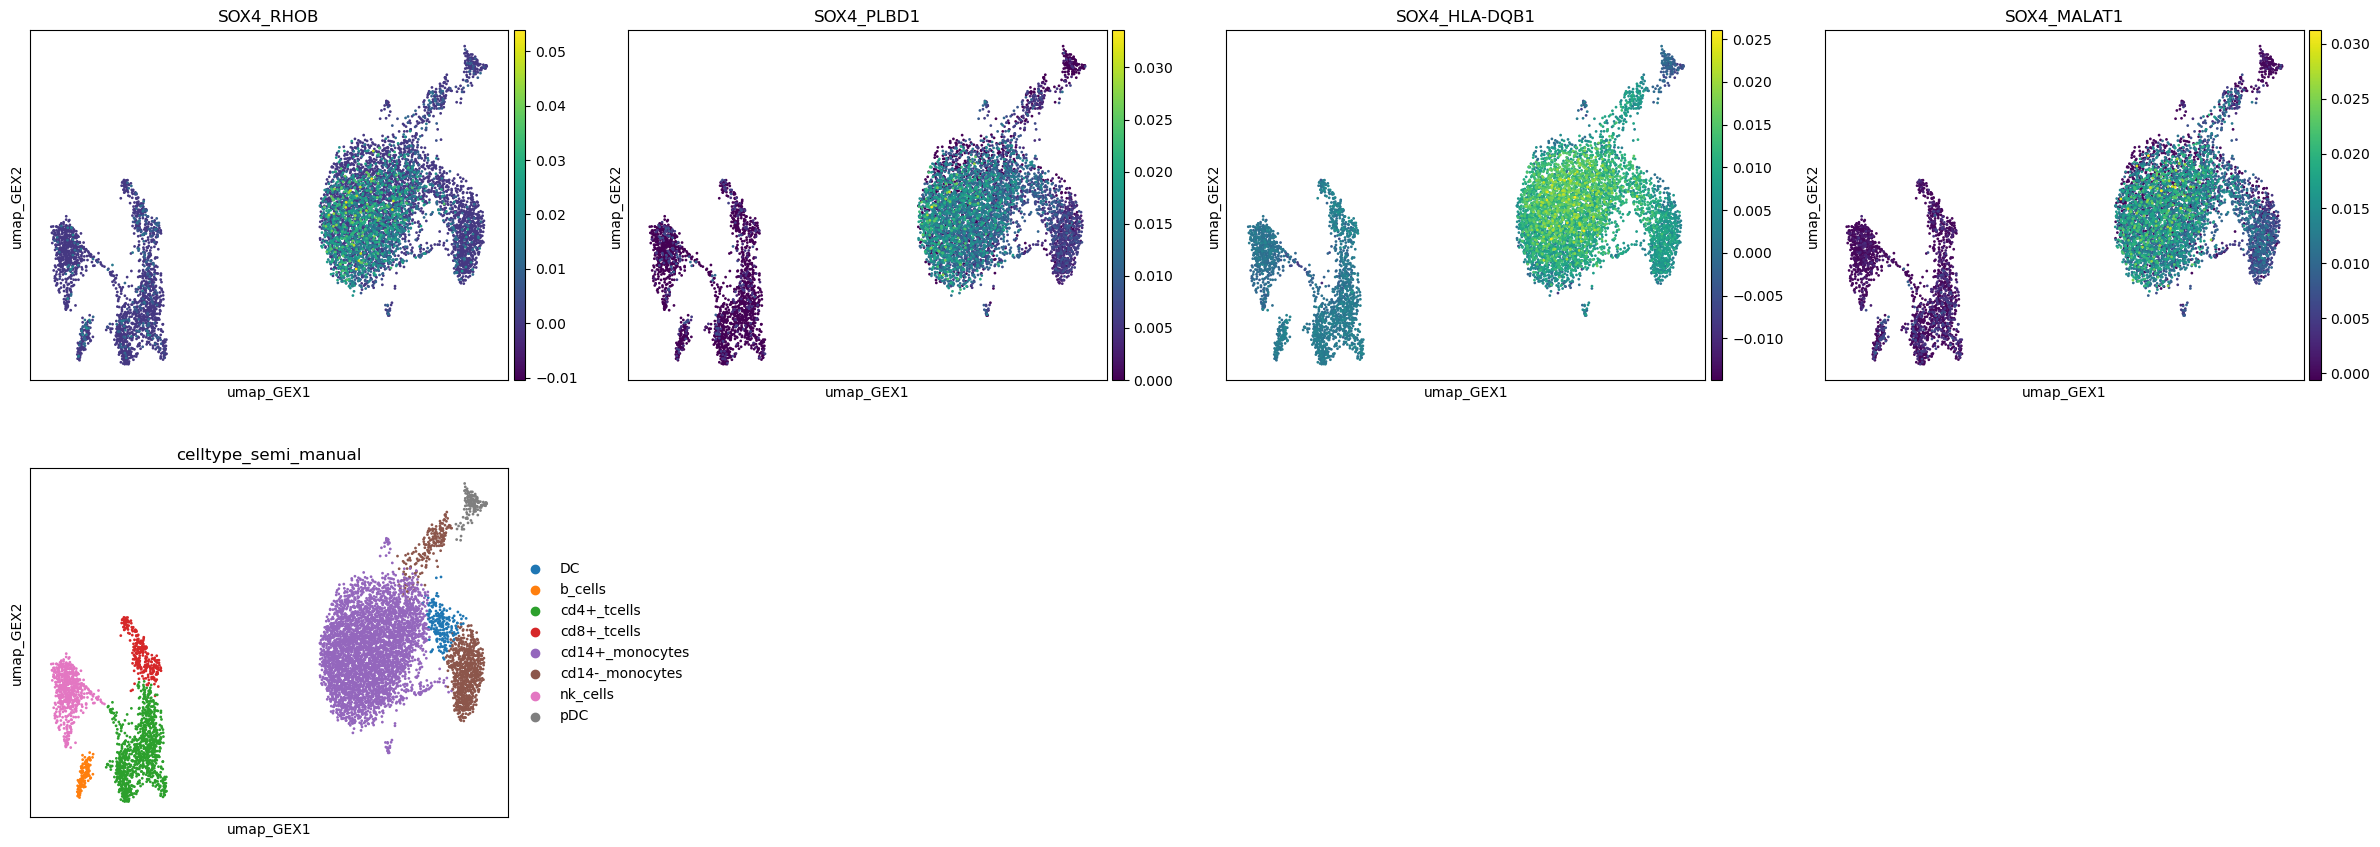

In [239]:
#grn_adata3.layers['masked_data'] = np.multiply(grn_adata3.layers['mask'], grn_adata3.X)
grn_adata3.obsm['umap_GEX'] = adata_raw.obsm['X_umap']
sc.pl.embedding(grn_adata3, color = list(edges)+['celltype_semi_manual'], basis='umap_GEX')

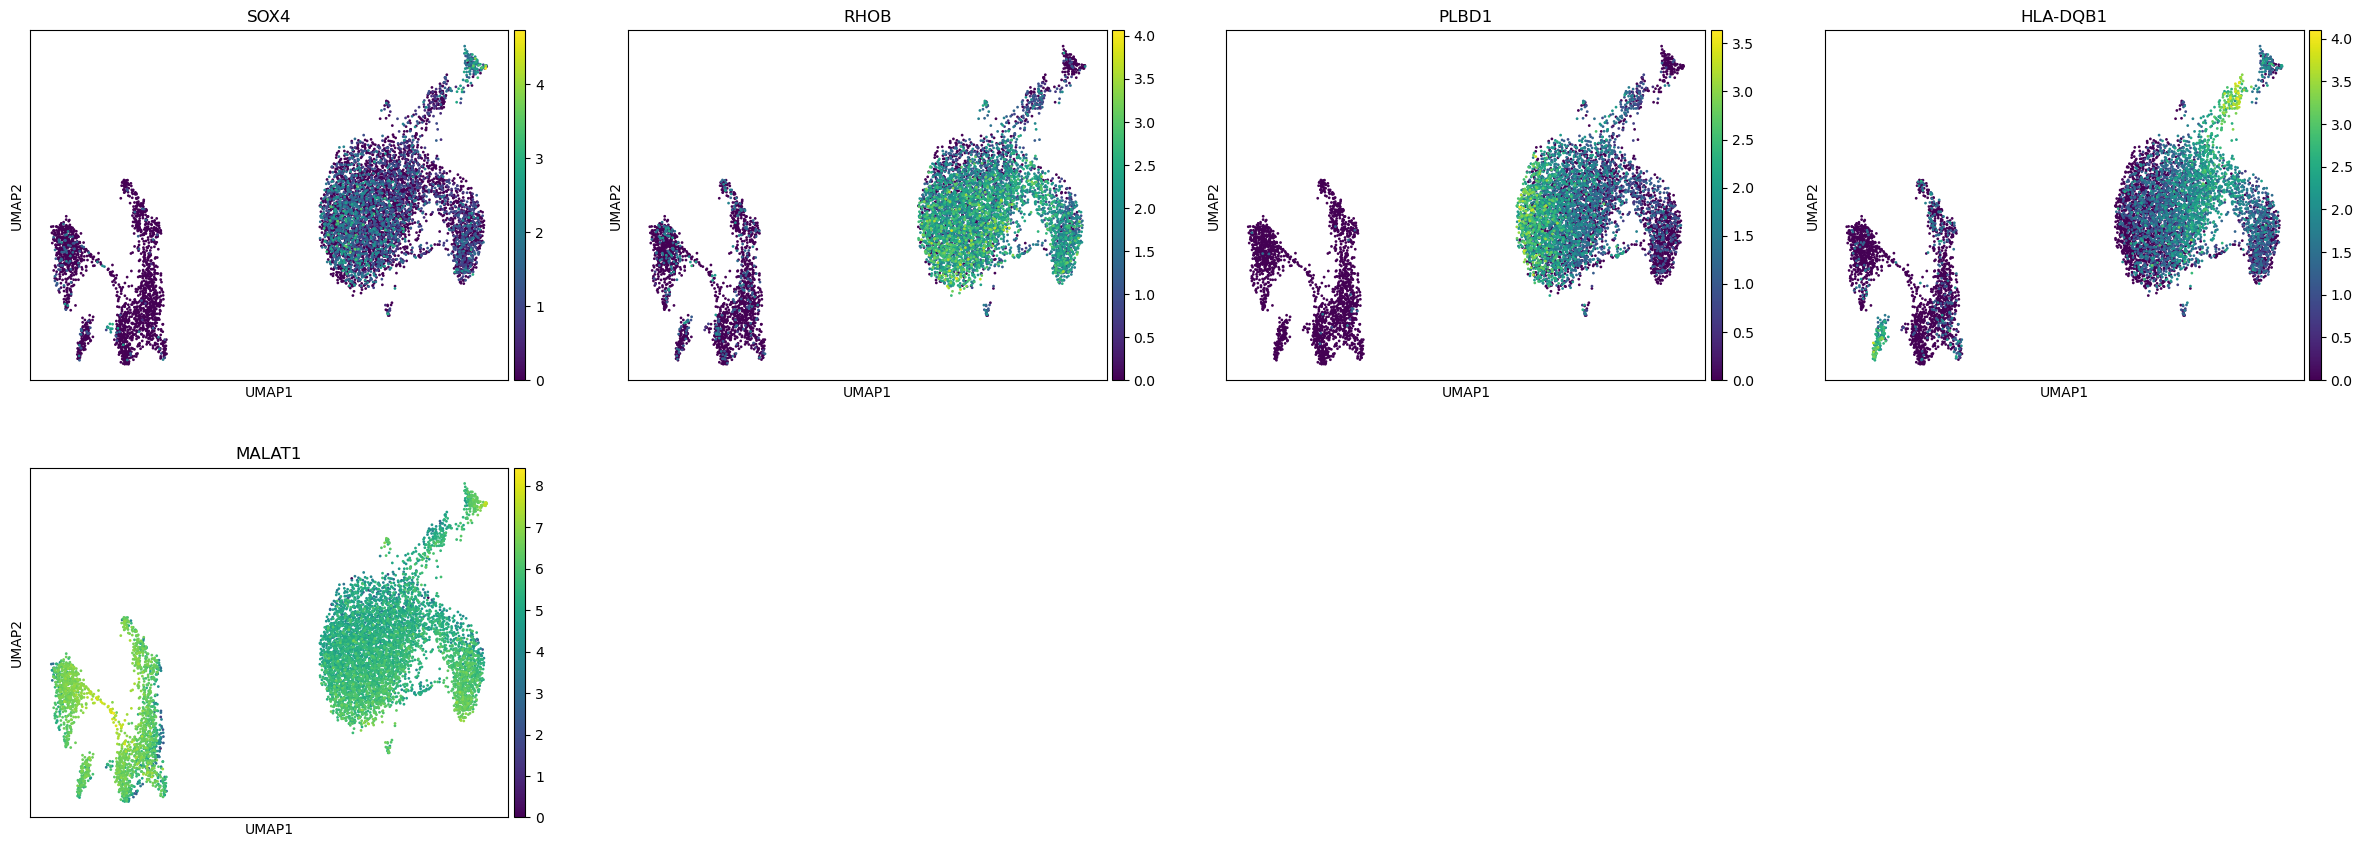

In [240]:
sc.pl.umap(adata_raw, color = [gene]+list(re_sub.target))

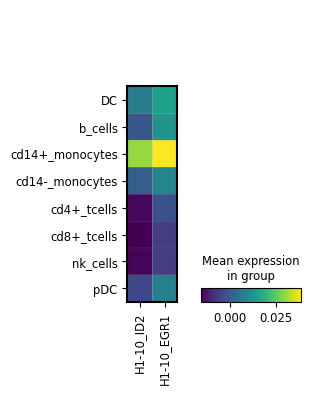

In [224]:
sc.pl.matrixplot(grn_adata3,  list(edges), groupby='leiden_remap')

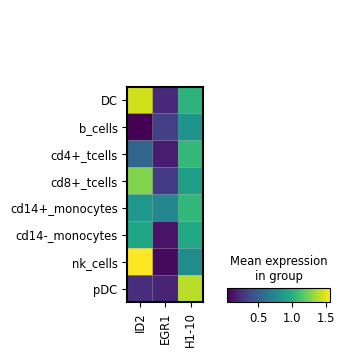

In [213]:
sc.pl.matrixplot(adata_raw, list(re_sub.target)+[gene], groupby='celltype_semi_manual' )

In [174]:
grn_adata3

AnnData object with n_obs × n_vars = 7610 × 152120
    obs: 'Unnamed: 0', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual', 'leiden_remap', 'celltypist'
    var: 'source', 'target', 'edge_sums', 'edge_means', 'count_nonzero', 'count_nonzero_norm', 'cd14+_monocytes_nonzero', 'cd14+_monocytes_candidate_edge', 'cd14-_monocytes_nonzero', 'cd14-_monocytes_candidate_edge', 'cd4+_tcells_nonzero', 'cd4+_tcells_candidate_edge', 'nk_cells_nonzero', 'nk_cells_candidate_edge', 'cd8+_tcells_nonzero', '

In [ ]:
# Plot a single regulon network
# Purpose:
#   Visualize the regulatory network associated with a specific
#   transcription factor (here: CEBPA). The plot typically includes
#   the source regulator and its top downstream targets, allowing
#   inspection of connectivity, target density, and regulatory structure.

os.makedirs('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/networks')
plot_reg(grn_adata3, regulon=["RASA2"], out_path='/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/')

['RASA2']
(218, 36)
path: /data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/networks/network.html
/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/networks/network.html
